In [409]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import interpolate
import scipy.integrate as integrate
from planeInterp import *

In [265]:
def line_interp_set(num):
    """sets up the baseline interpolator"""
    baseline1 = planeInterpolator(num)
    cone = baseline1.cone_interp() 
    elbow = baseline1.elbow_interp()
    connector = baseline1.cmd_interp("connector")
    middle = baseline1.cmd_interp("middle")
    diffuser = baseline1.cmd_interp("diffuser")
    return cone, elbow, connector, middle, diffuser

def line_interp(cone, elbow, connector, middle, diffuser, k, num = 50, unew = 0):
    """gives the kth line 0<=k<=359 num is a string and k is an interger"""
    """num if the number of points you want for the draft tube lines"""
    """the u values can also be defined specifically with unew"""
    x = []
    y = []
    z = []
    dist = 0.05
    i = 0
    for j in range(len(cone)):
        if k<180:
            if i == 0:
                x.append(cone[i][k+180][0])
                y.append(cone[i][k+180][1])
                z.append(cone[i][k+180][2]+0.10011979192495346)
                i = i+1
            else:
                xnext = cone[j][k+180][0]
                ynext = cone[j][k+180][1]
                znext = cone[j][k+180][2]+0.10011979192495346
                distance = (((xnext-x[i-1])**2) + ((ynext-y[i-1])**2) + ((znext-z[i-1])**2))**0.5
                #print(distance)
                if distance > dist:
                    x.append(xnext)
                    y.append(ynext)
                    z.append(znext)
                    i = i+1
        else:
            if i == 0:
                x.append(cone[i][k-180][0])
                y.append(cone[i][k-180][1])
                z.append(cone[i][k-180][2]+0.10011979192495346)
                i = i+1
            else:
                xnext = cone[j][k-180][0]
                ynext = cone[j][k-180][1]
                znext = cone[j][k-180][2]+0.10011979192495346
                distance = (((xnext-x[i-1])**2) + ((ynext-y[i-1])**2) + ((znext-z[i-1])**2))**0.5
                if distance > dist:
                    x.append(xnext)
                    y.append(ynext)
                    z.append(znext)
                    i = i+1
    a = i
    for j in list(range(0, 31)) + [63, 64, 32, 31] + list(range(33, 63)):
        if i-a == 0:
            x.append(elbow[i-a][k][0])
            y.append(elbow[i-a][k][1])
            z.append(elbow[i-a][k][2]+0.10011979192495346)
            i = i+1
        else:
            xnext = elbow[j][k][0]
            ynext = elbow[j][k][1]
            znext = elbow[j][k][2]+0.10011979192495346
            distance = (((xnext-x[i-1])**2) + ((ynext-y[i-1])**2) + ((znext-z[i-1])**2))**0.5
            if distance > dist:
                x.append(xnext)
                y.append(ynext)
                z.append(znext)
                i = i+1
        
    b = i
    for j in range(65):
        if i-b == 0:
            x.append(connector[i-b][k][0])
            y.append(connector[i-b][k][1])
            z.append(connector[i-b][k][2]+0.10011979192495346)
            i = i+1
        else:
            xnext = connector[j][k][0]
            ynext = connector[j][k][1]
            znext = connector[j][k][2]+0.10011979192495346
            distance = (((xnext-x[i-1])**2) + ((ynext-y[i-1])**2) + ((znext-z[i-1])**2))**0.5
            if distance > 0.005:
                x.append(xnext)
                y.append(ynext)
                z.append(znext)
                i = i+1
    
    b = i
    for j in range(65):
        if i-b == 0:
            x.append(middle[i-b][k][0])
            y.append(middle[i-b][k][1])
            z.append(middle[i-b][k][2]+0.10011979192495346)
            i = i+1
        else:
            xnext = middle[j][k][0]
            ynext = middle[j][k][1]
            znext = middle[j][k][2]+0.10011979192495346
            distance = (((xnext-x[i-1])**2) + ((ynext-y[i-1])**2) + ((znext-z[i-1])**2))**0.5
            if distance > 0.005:
                x.append(xnext)
                y.append(ynext)
                z.append(znext)
                i = i+1
    
    b = i
    for j in range(65):
        if i-b == 0:
            x.append(diffuser[i-b][k][0])
            y.append(diffuser[i-b][k][1])
            z.append(diffuser[i-b][k][2]+0.10011979192495346)
            i = i+1
        else:
            xnext = diffuser[j][k][0]
            ynext = diffuser[j][k][1]
            znext = diffuser[j][k][2]+0.10011979192495346
            distance = (((xnext-x[i-1])**2) + ((ynext-y[i-1])**2) + ((znext-z[i-1])**2))**0.5
            if distance > 0.005:
                x.append(xnext)
                y.append(ynext)
                z.append(znext)
                i = i+1
    if unew == 0:
        unew = np.array(np.linspace(0, 1, num, endpoint=False))
    tck, u = interpolate.splprep([x, y,z], s=0)
    xf, yf, zf = interpolate.splev(unew, tck, der = 0)
    return xf, yf, zf


In [64]:
cone1, elbow1, connector1, middle1, diffuser1 = line_interp_set("1")
cone4, elbow4, connector4, middle4, diffuser4 = line_interp_set("4")
cone5, elbow5, connector5, middle5, diffuser5 = line_interp_set("5")

In [420]:
numberPointsTube = 100
xf, yf, zf = line_interp(cone1, elbow1, connector1, middle1, diffuser1, 0, num = numberPointsTube)


In [417]:
x0, y0, z0= line_interp(cone1, elbow1, connector1, middle1, diffuser1, 0, num = numberPointsTube)
x179, y179, z179= line_interp(cone1, elbow1, connector1, middle1, diffuser1, 179, num = numberPointsTube)
x04, y04, z04 = line_interp(cone4, elbow4, connector4, middle4, diffuser4, 0, num = numberPointsTube)
x1794, y1794, z1794= line_interp(cone4, elbow4, connector4, middle4, diffuser4, 179, num = numberPointsTube)
x05, y05, z05= line_interp(cone5, elbow5, connector5, middle5, diffuser5, 0, num = numberPointsTube)
x1795, y1795, z1795= line_interp(cone5, elbow5, connector5, middle5, diffuser5, 179, num = numberPointsTube)

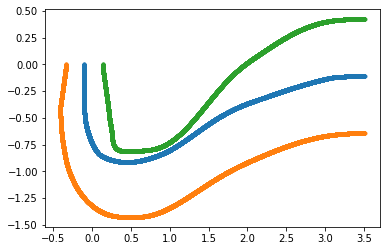

In [418]:
#points for origin line
#xorigin = [(x179[i]+x0[i])/2 for i in range(len(x0))]
#zorigin = [(z179[i]+z0[i])/2 for i in range(len(x0))]

xorigin = [(x179[i]+x0[i]+x1794[i]+x04[i]+x1795[i]+x05[i])/6 for i in range(len(x0))]
zorigin = [(z179[i]+z0[i]+z1794[i]+z04[i]+z1795[i]+z05[i])/6 for i in range(len(x0))]

# determine the line through of points for the origin line
plt.plot(xorigin, zorigin, ".")
#print(xorigin)

#interpolate the origin line
originPoints = [(xorigin[i], zorigin[i]) for i in range(len(xorigin))]
tck, u = interpolate.splprep((xorigin, zorigin), s=0)

plt.plot(x1795, z1795, ".")
plt.plot(x05, z05, ".")

In [419]:
#finding the length of the origin line, not needed??
length = 0
origindistance = []
for j in range(len(xorigin)-1):
    if j == 0:
        origindistance.append(((xorigin[j] - xorigin[j+1])**2 + (zorigin[j] - zorigin[j+1])**2)**0.5)
    else:
        origindistance.append((((xorigin[j] - xorigin[j+1])**2 + (zorigin[j] - zorigin[j+1])**2)**0.5) + origindistance[j-1])
total_length = origindistance[len(origindistance)-1]
print(total_length)

4.457477939137504


In [275]:
# getting the x values of the points on the origin line
numPlanes = 2000;
#points = np.linspace(0, 1, numPlanes, endpoint=False) #equal spacing
points = [(1-math.cos(math.pi*(2*(k+1)-1)/(2*numPlanes)))/2 for k in range(numPlanes)] #chebyshev spacing

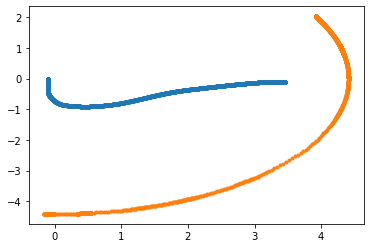

In [340]:
xPo, zPo= interpolate.splev(points, tck, der = 0)
xDer, zDer= interpolate.splev(points, tck, der = 1)
plt.plot(xPo, zPo, ".")
plt.plot(xDer, zDer, ".")
#plt.plot(x0, z0, ".")
#plt.plot(xf, zf, ".")

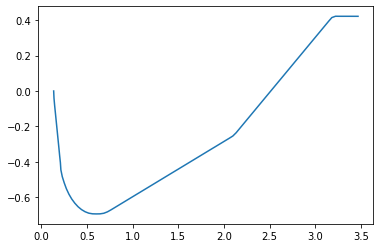

In [322]:
allLines = []
for i in range(360):
    xf, yf, zf = line_interp(cone1, elbow1, connector1, middle1, diffuser1, i, num = 100)
    linePoints = [[xf[j], yf[j], zf[j]] for j in range(len(xf))]
    allLines.append(linePoints)
linePoints = allLines[0]
xc = [linePoints[i][0] for i in range(len(linePoints))]
zc = [linePoints[i][2] for i in range(len(linePoints))]
#plt.plot(xc, zc)

In [402]:
newPlane = []
planeNum = 1600
point = [xPo[planeNum], 0, zPo[planeNum]] # location on origin line
d = np.dot(point, [xDer[planeNum], 0, zDer[planeNum]])
p_2 = [xDer[planeNum], 0, zDer[planeNum], d]
a = np.sqrt((xDer[planeNum])**2 + (zDer[planeNum])**2)
normal_vector = [xDer[planeNum]/a, 0, zDer[planeNum]/a]
p = Plane(Point3D(point[0], point[1], point[2]), normal_vector = (xDer[planeNum], 0, zDer[planeNum])) # perpendicular plane
for j in range(360):
    line = allLines[j]
    point1, point2 = closest2index2(line, normal_vector, point, planeNum/numPlanes)
    line = line[point1] + [line[point2][i]-line[point1][i] for i in range(3)]
    t = (p_2[3] - (p_2[0]*line[0] +p_2[1]*line[1]+  +p_2[2]*line[2]))/(p_2[0]*line[3] +p_2[1]*line[4] + p_2[2]*line[5])
    finalPoint = [(line[0]+t*line[3]), (line[1]+t*line[4]), (line[2]+t*line[5])]
    newPlane.append([finalPoint[0], finalPoint[1], finalPoint[2]])

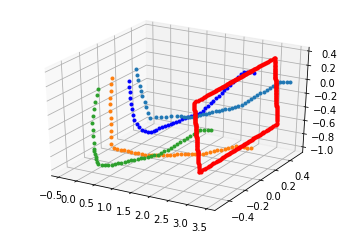

In [403]:
ax2 = plt.axes(projection='3d')
xf, yf, zf = line_interp(cone1, elbow1, connector1, middle1, diffuser1, 0, num = 50)
ax2.plot3D(xf, yf, zf, 'b.')
xf, yf, zf = line_interp(cone1, elbow1, connector1, middle1, diffuser1, 89, num = 50)
ax2.plot3D(xf, yf, zf, '.')
xf, yf, zf = line_interp(cone1, elbow1, connector1, middle1, diffuser1, 179, num = 50)
ax2.plot3D(xf, yf, zf, '.')
xf, yf, zf = line_interp(cone1, elbow1, connector1, middle1, diffuser1, 269, num = 50)
ax2.plot3D(xf, yf, zf, '.')
x = [newPlane[i][0] for i in range(len(newPlane))]
y = [newPlane[i][1] for i in range(len(newPlane))]
z = [newPlane[i][2] for i in range(len(newPlane))]
ax2.plot3D(x, y, z, "r.")

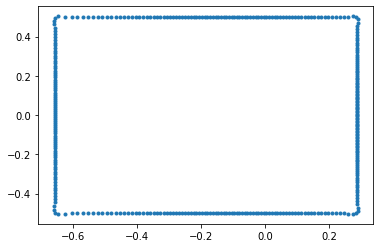

In [408]:
plt.plot(x, z, ".")
plt.plot(xorigin, zorigin, ".")

In [386]:
def closest2index2(linePoints, normal_vector, point, a):
    """points is a list of [x, y, z] points and plane is by [a, b, c, d], where ax+by+cz+d = 0"""
    # a is how far along the line the plane is from 0 to 1
    dist = []  
    #index = math.floor(a*len(linePoints)) # gives the index along the line that is near the point
    #b = math.floor(0.1*len(linePoints)) # 0.1 is arbitrary, need to choose a number that will limit search
    #print(index)
    #c = index - b
    #if c < 0 :
    #    c = 0
    #d = index+b
    #if d>len(linePoints):
    #    d = len(linePoints)
    #testPoints = np.array(np.linspace(c, d , d - c, endpoint=False))
    #print(testPoints)
    for i in range(len(linePoints)):
        #i = int(i)
        vector = [linePoints[i][0]-point[0], linePoints[i][1]-point[1], linePoints[i][2]-point[2]]
        normal_distance = np.abs(np.dot(vector, normal_vector))
        dist.append(normal_distance)
        distance = (((point[0]-linePoints[i][0])**2) + ((point[1]-linePoints[i][1])**2) + ((point[2]-linePoints[i][2])**2))**0.5
        if distance > 1:
            dist[i] += 10
    closest = min(range(len(dist)), key = lambda i: (dist[i]))
    dist1 = dist[closest]
    secondvalue = 1000
    for i in range(len(dist)):
        if dist[i] < secondvalue and dist[i] > dist1:
            second = i
            secondvalue = dist[i]
    return closest, second